In [207]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import palava

import statsmodels.api as sm

import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import igraph as ig


# Helper functons

In [208]:


def print_list(my_list):
  print("[", ", ".join(f"'{item}'" for item in my_list), "]")

def median_smooth_rows(arr, window_size=11):
    # Apply median filtering to each row of the array
    smoothed = np.apply_along_axis(lambda x: median_filter(x, size=window_size), axis=0, arr=arr)
    return smoothed


# Helper functions for the plots
def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix





In [209]:


adata = sc.read('data/fetal_liver_erythroid_with_50H.h5ad') 
pathways = [torch.tensor(i) for i in adata.uns['pathways_5000hvg']]

adata.X= adata.X.todense()
adata.X= np.array(adata.X)
adata


AnnData object with n_obs × n_vars = 43507 × 5000
    obs: 'nGene', 'nUMI', 'orig.ident', 'percent.mito', 'fetal.ids', 'sort.ids', 'tissue', 'lanes', 'stages', 'sample.type', 'gender', 'AnnatomicalPart', 'doublets', 'cell.labels', 'combined.labels', 'batch', 'sample', 'n_counts'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pathway_names', 'pathways_5000hvg'
    obsm: 'X_fdg', 'X_tsne', 'X_umap'
    layers: 'counts'

In [210]:

med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata_norm = sc.pp.log1p(adata_norm, copy = True)

sc.tl.pca(adata_norm, n_comps=6)


Median library size is 7095.0


In [211]:
num_unann = int(40)

pathway_names = adata.uns['pathway_names']
num_ann = pathway_names.shape[0]
pathway_names_plot = [pathway_names[i].replace('_', ' ' ).capitalize() + ' ['+str(i)+']'  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1) + ' ['+str(i+num_ann)+']'  for i in range(num_unann)]



In [212]:
gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)



In [213]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

In [214]:
dr = 'Out_files_and_results/fetal_erythropoesis/seed=1_lambda=0.5_list_of_nonlin_factors=none'


In [215]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

In [216]:
scvi_palava = SCVI_palava.load(file = dr+'/latent_and_slope_data/scvi_model', adata = adata)

factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]
factor_importance = factor_importance_dict['factor_importance']


/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/ssanthoshkum/.local/lib/python3.10/site-pa ...
  rank_zero_warn(
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/PALAVA-test/PALAVA/palava/model/base/_utils.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that c

Number of latent variables = 90: 50 annotated + 40 unannotated


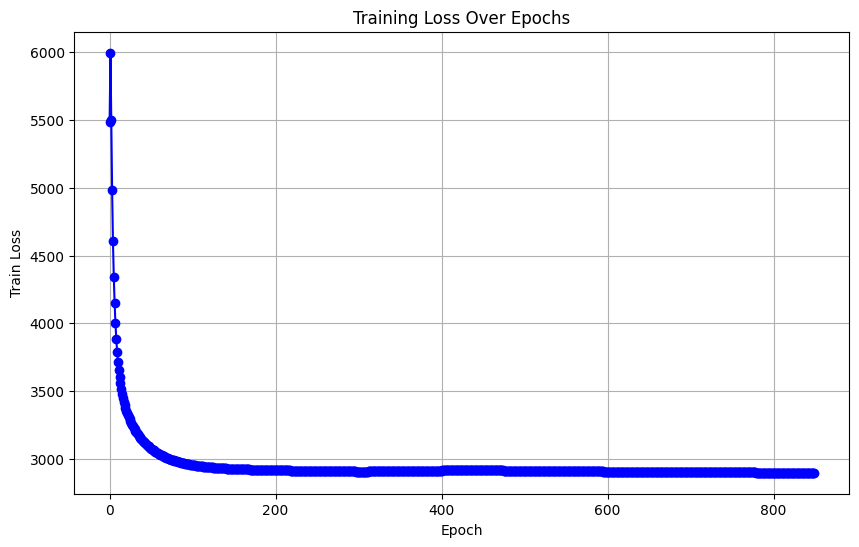

In [217]:

metric_to_plot = 'elbo_train'
df = scvi_palava.history[metric_to_plot]

plt.figure(figsize=(10, 6))

plt.plot(df.index, df[metric_to_plot], marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.grid(True)
plt.show()

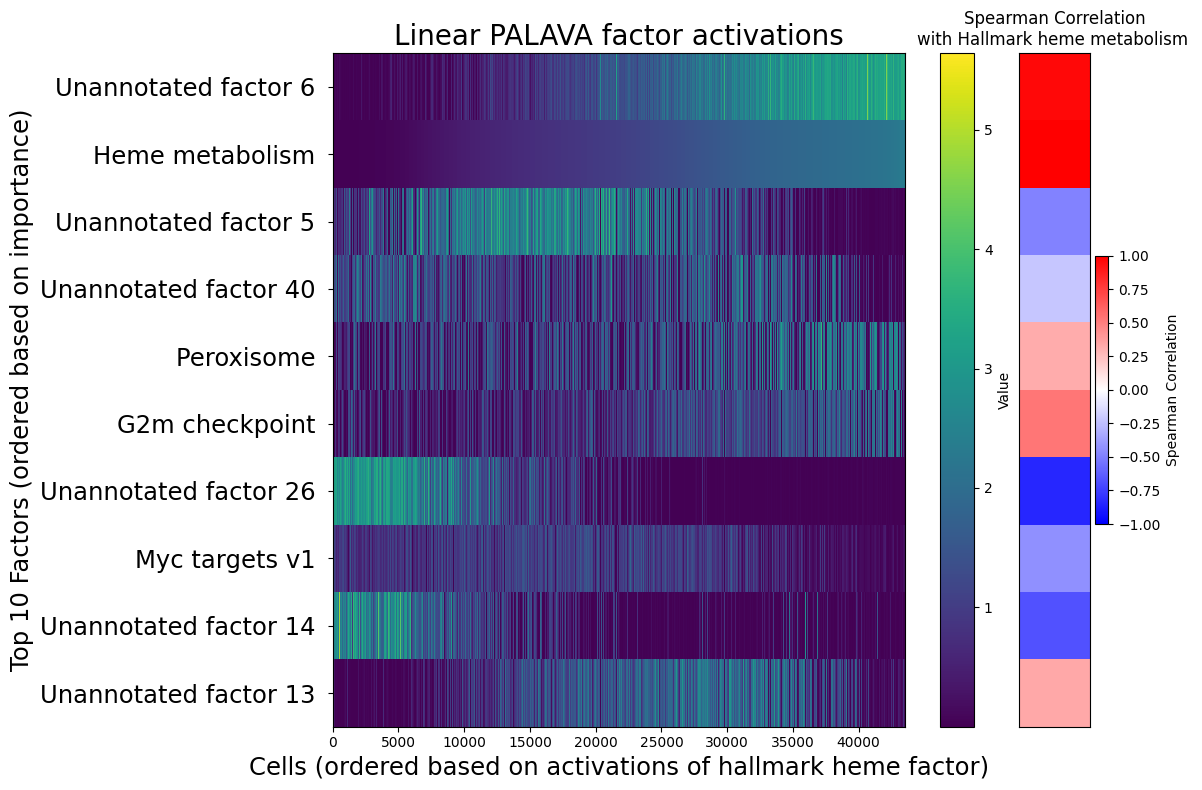

In [218]:

adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)
ind_sort = np.argsort(latent[:,  20])

n_top = 10
subset_indx = np.argsort(factor_importance)[::-1][:n_top]
data = learned_activations[subset_indx, :] # Replace with your actual data

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot[i] for i in subset_indx]
# Extract the ith row
i = 20  # Index of HEME factor 

target_row = learned_activations[i, :]

# Compute Spearman's correlation for each row with the target row
correlations = np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(data[:,ind_sort], aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("Linear PALAVA factor activations", fontsize = 20)
axes[0].set_xlabel("Cells (ordered based on activations of hallmark heme factor)", fontsize = 17.5)
axes[0].set_ylabel(f"Top {n_top} Factors (ordered based on importance)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 17.5)

plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest' ,vmin=-1, vmax=1)
axes[1].set_title(f"Spearman Correlation\nwith " +pathway_names_plot[i].split('[')[0])
axes[1].set_xticks([])  # Remove x-axis ticks for clarity
axes[1].set_yticks([])  # Remove y-axis ticks for clarity
plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')

# Adjust layout
plt.tight_layout()
plt.show()


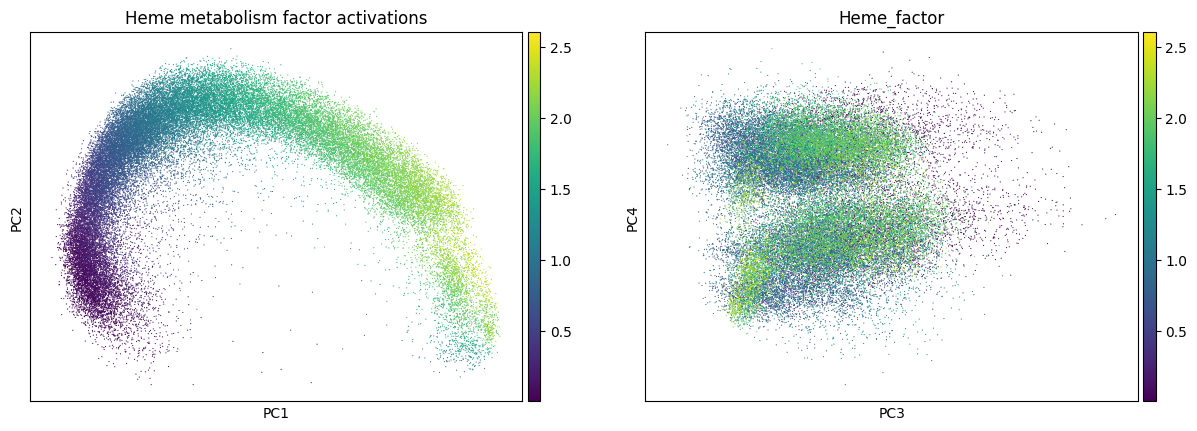

In [219]:
adata_norm.obs["Heme_factor"]  = adata.obsm['X_scVI'][:,20]

sc.pl.pca(adata_norm, color='Heme_factor', components=["1,2", "3,4"], title="Heme metabolism factor activations", ncols =2)
